# Topic: ML Underfitting Detection & High Bias

## Definition (30-second explanation)
* Underfitting occurs when a machine learning model is too simple to capture the underlying patterns in the training data.
* It results in poor performance on both the training data and new, unseen data.
* An underfitting model has high bias and low variance, meaning it makes strong, incorrect assumptions about the data.

## Why Interviewers Ask This
* To test your fundamental understanding of the bias-variance tradeoff, which is a core concept in machine learning.
* To evaluate your practical model debugging skills and see if you jump straight to complex solutions without checking training accuracy first.
* To check your ability to interpret learning curves correctly.

## Core Concepts
* **High Bias:** The model is too simple (e.g., using a linear model for highly non-linear data).
* **Low Variance:** The model is not overly sensitive to the training data and won't wildly change its predictions with new data.
* **Learning Curves:** Visual tools where underfitting is indicated by both training and validation losses being high and close together (flat curves).

## When to Use (How to Identify)
* When your model shows low accuracy on both training data and test data.
* When a complex dataset is being modeled with a simplistic algorithm.
* When raw features are used directly without any feature engineering.
* When the model was trained with excessive regularization.

## Fixes (Advantages of applying them)
* **Increase Model Complexity:** Switch to a more complex model (e.g., from Logistic Regression to Random Forest or Gradient Boosting).
* **Feature Engineering:** Add more features, or create polynomial/interaction features to give the model more capacity to learn.
* **Reduce Regularization:** Decrease the strength of L1 or L2 regularization to allow the model to fit the data closer.
* **Increase Epochs:** If using neural networks, simply train for more epochs.

## Limitations (What NOT to do)
* **Never add more data:** Adding more training data rarely fixes a model that is already too simple to learn the existing data.
* **Do not increase regularization:** Applying more regularization will constrain an already under-constrained model, worsening the underfitting.

## Common Comparisons
* **Underfitting vs. Overfitting:** Underfitting means low training AND test accuracy (high bias); Overfitting means high training accuracy but low test accuracy (high variance).

## Common Interview Traps
* **Mistake 1:** Assuming low test accuracy *alone* means underfitting—you must check training accuracy too.
* **Mistake 2:** Stating you would "get more data" to fix the poor performance.
* **Pro-Tip:** Always propose at least two or three fixes (e.g., model complexity, features, regularization) to show breadth of knowledge.

## Python / SQL Syntax
```python
# Detecting underfitting using learning curves
from sklearn.model_selection import learning_curve
import numpy as np

# Calculate learning curves for the model
train_sizes, train_scores, val_scores = learning_curve(
    simple_model, X, y, train_sizes=np.linspace(0.1, 1.0, 10), scoring="r2", cv=5
) #

train_mean = np.mean(train_scores, axis=1) #
val_mean = np.mean(val_scores, axis=1) #

# Underfitting logic: Both scores low and close together
if train_mean[-1] < 0.75 and abs(train_mean[-1] - val_mean[-1]) < 0.1:
    print("UNDERFITTING DETECTED") #
```

## Important Formula: 
- Bias-Variance Tradeoff: 
    $Total Error = Bias^2 + Variance + Irreducible Noise$

## 45-Second Interview Answer
"Underfitting occurs when a model is too simple to capture the underlying patterns, resulting in high bias, low variance, and poor performance on both training and test sets. I detect this by looking at learning curves; if training and validation errors plateau at a high error rate and remain close together, the model is underfitting. To fix it, I would first try increasing model complexity by switching to a non-linear algorithm like a Random Forest, engineering new polynomial features, or reducing the strength of my regularization parameters. I would never suggest gathering more data, as a simple model cannot learn from it anyway."

## Example Questions:

### Q1: What is the difference between underfitting and overfitting? How do you detect each?
* **Ideal Answer:** Underfitting is when a model is too simple, yielding high bias and low variance. You detect it when both training and test accuracy are low. Overfitting is when a model is too complex, yielding low bias and high variance. You detect it when training accuracy is high, but test accuracy is low. 
* **Common Mistakes:** Forgetting to mention checking the training accuracy before diagnosing the problem.
* **Follow-up:** How do learning curves visually differentiate the two? (Answer: Underfitting shows both curves plateauing close together at a high error rate. Overfitting shows a large gap between the low training error curve and the high validation error curve).

### Q2: You train a neural network with 2 layers and get 60% training accuracy. What should you do?
* **Ideal Answer:** Because the training accuracy is very low, the network is underfitting the data. I would fix this by increasing the model's capacity—specifically by adding more hidden layers, increasing the number of neurons per layer, or training for more epochs. I would also check if my regularization (like Dropout or L2) is too high and reduce it.
* **Common Mistakes:** Suggesting gathering more data, which won't help a 2-layer network that already can't learn the current data.
* **Follow-up:** What if you increase it to 10 layers and the training accuracy stays at 60%? (Answer: I would check for vanishing gradients, ensure my learning rate isn't too small, or verify that the data itself isn't pure noise).

### Q3: Your learning curves show that both training and validation loss are high and flat. What does this mean?
* **Ideal Answer:** This is the classic signature of high bias, meaning the model is underfitting. The flat curves indicate that adding more training data will not improve performance. We must increase the complexity of the model or the feature set to break the plateau.
* **Common Mistakes:** Recommending cross-validation or more data to fix the plateau.
* **Follow-up:** Which specific algorithm would you switch to if you saw this while using a Logistic Regression? (Answer: A non-linear tree-based model like a Random Forest or Gradient Boosting machine).

### Q4: How does regularization contribute to underfitting? Give an example.
* **Ideal Answer:** Regularization penalizes model complexity to prevent overfitting. If the penalty is too strong, it forces the model weights too close to zero, removing the model's ability to capture actual patterns, leading to underfitting. For example, setting the 'alpha' or 'C' parameter too aggressively in a Ridge Regression or SVM will cause it to underfit.
* **Common Mistakes:** Confusing the direction of the regularization parameter (e.g., thinking a high 'C' in SVM causes underfitting, when actually a low 'C' increases regularization and causes underfitting).
* **Follow-up:** How does L1 regularization specifically cause underfitting compared to L2? (Answer: L1 drives weights to exactly zero, effectively dropping features entirely. If it drops too many important features, the model loses vital information and underfits).

### Q5: What is the relationship between model complexity and underfitting?
* **Ideal Answer:** There is an inverse relationship. As model complexity decreases, the risk of underfitting (high bias) increases. A model with low complexity cannot capture the intricate non-linear relationships in complex data, leading to a high total error. 
* **Common Mistakes:** Failing to explicitly mention the bias-variance tradeoff framework in the answer.
* **Follow-up:** Can you increase model complexity without changing the algorithm itself? (Answer: Yes, by doing feature engineering—specifically adding polynomial features, interaction terms, or reducing dimensionality reduction constraints).

## Practice Questions:

### Q1:
**The simple LinearRegression model above is heavily underfitting the cubic non-linear data.**

**Using scikit-learn, write the Python code to fix this underfitting by transforming the input feature X into polynomial features of degree 3, and then train a new Ridge regression model (with alpha=0.1) on these transformed features. Calculate and print the new MSE.**

In [ ]:
# Data:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Generate non-linear mock data
np.random.seed(42)
X = 2 - 3 * np.random.normal(0, 1, 100)
y = X - 2 * (X ** 2) + 0.5 * (X ** 3) + np.random.normal(-3, 3, 100)

X = X[:, np.newaxis] # Shape (100, 1)

# Current Model (Underfitting)
model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
print("Current MSE:", mean_squared_error(y, y_pred)) # Outputs a very high error

Current MSE: 813.1848021581824


In [6]:
# Answer:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Create a pipeline that first transforms the data, then fits the model
# This prevents data leakage during cross-validation
model = make_pipeline(
    PolynomialFeatures(degree=3, include_bias=False),
    Ridge(alpha=0.1)
)

model.fit(X, y)
y_pred = model.predict(X)
print("Ridge MSE:", mean_squared_error(y, y_pred))

Ridge MSE: 7.570048390296649


* **Interview Tips:** Always suggest using `sklearn.pipeline.Pipeline` or `make_pipeline` when chaining transformers (like `PolynomialFeatures`) and estimators. Interviewers look for this to ensure you know how to avoid data leakage in production systems.
* **Common Mistakes:** Applying `fit_transform` on both the training AND the test set separately. You must only `fit` on the training set, and `transform` the test set. (A `Pipeline` handles this automatically).
* **Follow-up:** "Why did we switch to Ridge regression instead of keeping the standard Linear Regression after adding polynomial features?" (Answer: Polynomial features drastically increase the feature space, which can lead to rapid overfitting. Ridge adds L2 regularization to control the weights of those new polynomial features, keeping the model balanced).

### Q2:
You are building a Fraud Detection model for a bank. You train a Logistic Regression model with strong L1 regularization because the compliance team requires the model to be highly interpretable (they need to know exactly which features drive a fraud decision).

Your model yields a 65% training accuracy and a 63% test accuracy. The business target is 85%.

You identify this as underfitting. However, the compliance team strictly forbids you from switching to complex, "black-box" models like Random Forest, Gradient Boosting, or Neural Networks.

Without changing the Logistic Regression algorithm, give me two specific ways you would fix this underfitting problem.

**Answer:** "Since I cannot switch to a more complex algorithm like a Random Forest, I would increase the capacity of the current model in two ways. First, I would drastically reduce or remove the L1 regularization, which is likely forcing too many feature weights to zero and preventing the model from learning. Second, I would perform aggressive feature engineering, specifically creating interaction features or polynomial features. This allows the model to capture non-linear patterns while maintaining a highly interpretable linear equation for the compliance team."
* **Interview Tips:** When given a constraint (e.g., "must be interpretable" or "low latency required"), acknowledge it immediately in your answer. Proposing a neural network here would result in an automatic fail for ignoring business requirements. 
* **Common Mistakes:** Suggesting PCA (Principal Component Analysis) to create new features. PCA reduces dimensionality and destroys interpretability, which violates the compliance team's constraints.
* **Follow-up:** "If you remove the L1 regularization and the model suddenly jumps to 95% training accuracy but drops to 50% test accuracy, what happened and how do you proceed?" (Answer: The model transitioned from underfitting to overfitting. I would systematically reintroduce a mild L2 regularization penalty or perform feature selection to remove noisy engineered features).

### Q3: Write Python code to calculate and plot a learning curve to detect underfitting.

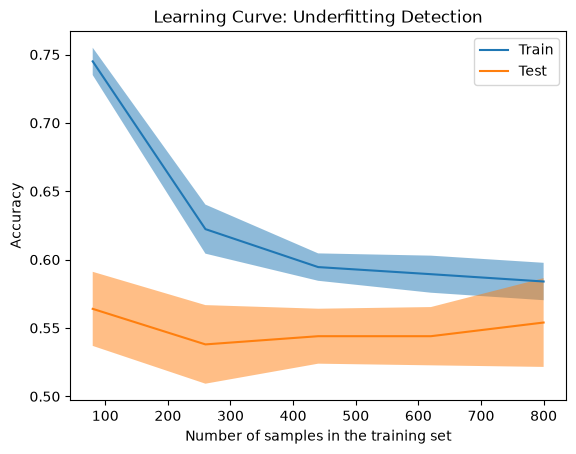

Underfitting Detected: Training and validation curves have converged at a low accuracy, meaning the model is too simple to learn the data.


In [11]:
from sklearn.model_selection import learning_curve, LearningCurveDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Calculate the learning curve scores
train_sizes, train_scores, val_scores = learning_curve(
    estimator=model, X=X, y=y, cv=5, scoring='accuracy'
)

# 2. Modern Scikit-Learn Plotting (Alternative to manual plt.plot)
display = LearningCurveDisplay(
    train_sizes=train_sizes,
    train_scores=train_scores,
    test_scores=val_scores,
    score_name='Accuracy'
)
display.plot()
plt.title("Learning Curve: Underfitting Detection")
plt.show()

# 3. Calculate final mean scores to check the plateau programmatically
train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

if train_mean[-1] < 0.75 and abs(train_mean[-1] - val_mean[-1]) < 0.1:
    print("Underfitting Detected: Training and validation curves have converged at a low accuracy, meaning the model is too simple to learn the data.")

* **Interview Tips:** Using `LearningCurveDisplay` in a live coding interview demonstrates strong, up-to-date knowledge of the `scikit-learn` API, saving you from writing tedious boilerplate `matplotlib` code. Always explicitly state that you are looking for two things on an underfitting graph: 
- 1) the curves are close together (low variance), and 
- 2) the curves plateau at a poor score (high bias).
* **Common Mistakes:** Forgetting to aggregate the cross-validation folds. The `learning_curve` function returns a 2D array of shape `(n_ticks, n_cv_folds)`. You must use `.mean(axis=1)` to get the average score for each training size before you can logically evaluate it.